# AAI6610 Module 5.5 - Deep Learning Model for Predicting Credit Risk



In [2]:
'''
Author: Michael Zimmerman
Date: Febuary 2026

Deep Learning Model for Credit Risk Prediction Pipeline

This notebook is design to implement a deep learning neural network model to predict credit card default risk using  the UCI Default of Credit Card dataset from Tawian. 
Performance will be compared against the Module 3 assignment which utilize statistical models: Logistic Regression, Random Forests and LightGBM. 
'''


# ==============================
# IMPORTS AND LIBARIES 
# ==============================

# Core Data Libraries for Data manipulation and numerical operations
import pandas as pd 
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities 
from sklearn.model_selection import train_test_split # for creating test/train split. This has been used in a previous assignment and will be reused 
from sklearn.preprocessing import StandardScaler # neural networks required to be scaled 
from sklearn.utils.class_weight import compute_class_weight # decided to handle the class imbalances from last assignment with class weights instead of over/under sampling.
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix, # visualize for false positives/negatives
    classification_report
)

# TensorFlow/Keras for deep learning model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential  # linear stack of layers
from tensorflow.keras.layers import Dense, Dropout  # Dense for fully connected layers, Dropout for regularization to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping  # to prevent overfitting, halts training during validation performance degradation
from tensorflow.keras.optimizers import Adam  # algorithm learning rate optimizer for the training process

# Confirm imports have loaded correctly 
print("-" * 50)
print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print("-" * 50)

--------------------------------------------------
All libraries imported successfully!
TensorFlow version: 2.20.0
--------------------------------------------------


### Random Seeds and display settings

In [3]:
''' from Assignment 3 compatiability. RANDOM_STATE_A3, or random state for assignment 3 will be for the train/test split ONLY. 
Need to match exactly.

I moved it to the global settings for best practices 
'''
RANDOM_STATE = 2020
TEST_SIZE = 0.2 




# Set global random seeds for reproducibility for numpy and tensorflow (Set seed value)
RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


# display settings for pandas and seaborn and readability 
pd.set_option('display.max_columns', None) # show all columns in dataframe
pd.set_option('display.width', 100) #set max width for display


print("-" * 50)
print("Randomness and Test Size Configured from A3!")
print(f"Random state parameters : {RANDOM_STATE}")
print("-" * 50)
print("Random Seed has been set for reproducibility and displays have been formatted!")
print(f"Random seed's parameters : {RANDOM_SEED}")
print("-" * 50)

--------------------------------------------------
Randomness and Test Size Configured from A3!
Random state parameters : 2020
--------------------------------------------------
Random Seed has been set for reproducibility and displays have been formatted!
Random seed's parameters : 2026
--------------------------------------------------


### Data Loading & Feature Creation

In [4]:
# ==============================
# DATA PROCESSING & EXPLORATION 
# ==============================

# Load the dataset 
# read the csv file into a dataframe
df = pd.read_csv('/Users/djmike20/Documents/NU - Applied AI/AAI6610 - Applied Machine Learning/Module 3/aai6610_credit_risk_pipeline/dataset/default_of_credit_card_clients.csv')

print("-" * 50)
print("Dataset loaded successfully!")
print(f"Data shape: {df.shape}")
print("-" * 50)

#========================Setting up Features and Target==============================================

# Target and Drop column from dataset 
TARGET_COLUMN = 'default payment next month'
DROP_COLUMNS = ['ID' , 'default payment next month'] 


# create X (features) and y (target)
y = df[TARGET_COLUMN].values
X = df.drop(columns=DROP_COLUMNS).values

# store features names for later for interpretability and visualization use
df_features = df.drop(columns=DROP_COLUMNS).columns.tolist()

# check updated shapes with newly dropped columns
print("Feature and Target Shapes: \n")
print(f'Features Shape: {X.shape}')
print(f'Target Shape: {y.shape}')
print("-" * 50)
print(f"Number of features: {len(df_features)}")
print(f"Feature Names: {df_features[:5]}") # print the first 5 features

print("=" * 70)





--------------------------------------------------
Dataset loaded successfully!
Data shape: (30000, 25)
--------------------------------------------------
Feature and Target Shapes: 

Features Shape: (30000, 23)
Target Shape: (30000,)
--------------------------------------------------
Number of features: 23
Feature Names: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE']


### Train/Test Split, Scaling and Class Weights

In [5]:
'''
This cell will be used to mirror the train/test split from assignment 3.

Its important to do so to ensure that the same data is being used for training and testing and call for a fair comparison 
between the statistical models versus the deep learning model.
'''

# call RANDOM_STATE and TEST_SIZE to get exact split from assignment 3
X_train, X_test, y_train, y_test = train_test_split(
            X, y, 
            test_size=TEST_SIZE, 
            random_state=RANDOM_STATE
)

print("-" * 50)
print(f"Random state parameters : {RANDOM_STATE}")
print(f'Training Set Shape: {X_train.shape[0]:,} samples')
print(f'Test Set Shape: {X_test.shape[0]:,} samples')
print("-" * 50)
print(f'Number of positive samples in training set: {np.sum(y_train)}')
print(f'Number of positive samples in test set: {np.sum(y_test)}')
print(f'Training default rate: {np.mean(y_train):.4f}')
print(f'Training default rate: {np.mean(y_test):.4f}')
print("-" * 50)
print("Train/Test split completed successfully with the same parameters as Assignment 3!")



# ============================= FEATURE SCALING =============================
'''
Neural networks require feature scaling for optimal performance
'''
# initialize StandardScaler for scaling 
scaler = StandardScaler()

# fit the scaler on the training data then transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

print(f'Training Set Shape: {X_train_scaled.shape[0]}')
print(f'Test Set Shape: {X_test_scaled.shape[0]}')

'''
In Assignment 3, we identified the dataset had an imbalance of the target classes, with a default rate of 22.1%
To address this, will compute the class weights on the training data to give more importance to the minority class during training.

Resources: https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
'''

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train), # returns an assorted array of unique class labels
    y=y_train
)

# creating a dictionary to pass to the Keras model and to map and penalize mistakaes in the default class more heavily during training. Required for Keras API
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("-" * 50)
print("Class weights computed successfully!\n")
print(f"Non-Default (Class 0) weight: {class_weight_dict[0]:.4f}")
print(f"Default (Class 1) weight: {class_weight_dict[1]:.4f}")
print(f"Ratio: {class_weight_dict[1]/class_weight_dict[0]:.4f}")




--------------------------------------------------
Random state parameters : 2020
Training Set Shape: 24,000 samples
Test Set Shape: 6,000 samples
--------------------------------------------------
Number of positive samples in training set: 5271
Number of positive samples in test set: 1365
Training default rate: 0.2196
Training default rate: 0.2275
--------------------------------------------------
Train/Test split completed successfully with the same parameters as Assignment 3!
Training Set Shape: 24000
Test Set Shape: 6000
--------------------------------------------------
Class weights computed successfully!

Non-Default (Class 0) weight: 0.6407
Default (Class 1) weight: 2.2766
Ratio: 3.5532


### Build out the Neural Network

In [6]:
'''
This section will be used to build out the deep learning model architechture. 
Then compile the model with the appropriate loss function, optimizer and evaluation metrics

Using activation functions, dropout and early stopping to prevent overfitting and improve generalization
    - 1 x input layer (# of features)
    - 3 x hidden layers with ReLU activation and dropout for regularization, may had Leaky ReLU if performancr is poor and gradient is vanishing
    - 1 x outpput ;ayer with sigmoid activation for binary classification
ReLU activation for hidden layers. 
    Both activation functions are non-linear, allowing the model to learn from complex patterns within the hidden layers

Will be using Tensorflow/Keras for the build out 
Will use Sequential API for linear layers


- Decreasing hidden layers neurons (64>32>16) to specify the layer pattern size for the 3 layers 

- Dense: Z = (input x weights) + bias (linear math)
Then ReLU and Sigmoid is applied after the linear math is done

- Relu is the result is negative, turn it to 0, if positive keep the same value
- Sigmoid, squash the output to a value between 0 and 1


Resources:
https://keras.io/guides/sequential_model/
'''


model = Sequential([
    # Input + First Hidden Layer, 23 is used because there are 23 features 
    Dense(64, activation='relu', name='hidden_layer_1', input_shape=(23,)),
    Dropout(0.3, name='dropout_1'),
    
    # Second Hidden Layer 
    Dense(32, activation='relu', name='hidden_layer_2'),
    Dropout(0.3, name='dropout_2'),
    
    # Third Hidden Layer
    Dense(16, activation='relu', name='hidden_layer_3'),
    Dropout(0.2, name='dropout_3'),
    
    # Output Layer 
    Dense(1, activation='sigmoid', name='output_layer')  
])

print("-" * 50)
print("Model architecture created successfully!\n")
print("-" * 50)

--------------------------------------------------
Model architecture created successfully!

--------------------------------------------------


/Users/djmike20/Documents/NU - Applied AI/AAI6610 - Applied Machine Learning/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Compile the model 

In [7]:
# ============ Compile the model ==============

'''
- uses  binary cross-entropy for loss function
    loss function handles binary classification problems and meassures between predicted and actual probabilities, which is appropriate for this credit risk prediction task.
- Adam optimizer for training 
- metrics for evaluation

Resources: https://keras.io/api/metrics/
'''
# used for metrics, optimzier, and loss function 
# for configuration and not compute 
model.compile(
    optimizer=Adam(learning_rate=0.001), # adam with a learning rate of 0.001 for efficient training and convergence
    loss='binary_crossentropy', 
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]  
)

print ("-" * 50)
print('Optimzer, Loss Function and Metrics configured successfully!\n')
print(f"Optimizer: Adam with learning rate of {model.optimizer.learning_rate.numpy():.4f}")
print(f"Loss Function: Binary Cross-Entropy")
print(f"Metrics: Accuracy, AUC, Precision, Recall")
print("-" * 50)
print()

--------------------------------------------------
Optimzer, Loss Function and Metrics configured successfully!

Optimizer: Adam with learning rate of 0.0010
Loss Function: Binary Cross-Entropy
Metrics: Accuracy, AUC, Precision, Recall
--------------------------------------------------



#### Train the model 

In [8]:
# ============ Train the Neural Network ==============

# Setting up early stopping to monitor validation loss and prevent overfitting
'''
Resources: https://keras.io/api/callbacks/early_stopping/

''' 

early_stop = EarlyStopping(
    monitor="val_loss", # monitor validation loss to determine when to stop training 
    patience=10,
    restore_best_weights=True, # restore the best weights observed during training for optimal performance on test set 
    verbose=1 # prints a message when early stopping is triggered    
)

print("-" * 50)
print("Early stopping configured successfully!\n")
print(f"Monitoring: {early_stop.monitor}")
print(f"Patience: {early_stop.patience} epochs")


print("-" * 50)
print("Start model Training...\n")
print("-" * 50)
# ============ Train and Fit the model ==============
'''
Resources: https://keras.io/api/models/model_training_apis/

Training Configs 
Epochs
Training data: X_train_scaled, y_train  
Validation 
''' 


history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100, # the high number of epochs helps early stopping determine optimal training duration 
    batch_size=32, # number of samples per gradient update 
    validation_split=0.2, # use 20% of training data for validation
    class_weight=class_weight_dict, # pass the computed class weights to handle class imbalance during training
    callbacks=[early_stop], 
    verbose=1
)


print("-" * 50)
print("Training is Complete!\n")
print("-" * 50)


--------------------------------------------------
Early stopping configured successfully!

Monitoring: val_loss
Patience: 10 epochs
--------------------------------------------------
Start model Training...

--------------------------------------------------
Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6459 - auc: 0.6895 - loss: 0.6365 - precision: 0.3335 - recall: 0.6238 - val_accuracy: 0.7775 - val_auc: 0.7333 - val_loss: 0.5936 - val_precision: 0.5062 - val_recall: 0.5277
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - accuracy: 0.7631 - auc: 0.7242 - loss: 0.6083 - precision: 0.4628 - recall: 0.5326 - val_accuracy: 0.7802 - val_auc: 0.7468 - val_loss: 0.5742 - val_precision: 0.5119 - val_recall: 0.5351
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step - accuracy: 0.7648 - auc: 0.7439 - loss: 0.5954 - precision: 0.4674 - recall: 0.5605 - val_accuracy: 0.7758 - val_auc: 0.7546 - val_loss: 0.5689 - val_precision: 0.5026 - val_recall: 0.5388
Epoch 4

#### Display Final Training Metrics 

In [9]:
final_epoch = len(history.history['loss'])

# final Training Loss 
# using negative indexing to get the last value in the calculated metrics history 
final_training_loss = history.history['loss'][-1]
final_train_acc = history.history["accuracy"][-1]
final_train_auc = history.history["auc"][-1]
final_train_precision = history.history["precision"][-1]
final_train_recall = history.history["recall"][-1]

# final Validation Loss
final_validation_loss = history.history["val_loss"][-1]
final_validation_acc = history.history["val_accuracy"][-1]
final_validation_auc = history.history["val_auc"][-1]
final_validation_precision = history.history["val_precision"][-1]
final_validation_recall = history.history["val_recall"][-1]

# print training duration and final epoch
print("=" * 55)
print("TRAINING SUMMARY:")
print("=" * 55)
print(f"Total Epochs Trained & Early Stopping Triggered at: {final_epoch}")
print("-" * 55)

print(f"\nFinal Training Metrics:")
print(f" Loss: {final_training_loss:.4f}")
print(f" Accuracy: {final_train_acc:.4f}")
print(f" AUC: {final_train_auc:.4f}")
print(f" Precision: {final_train_precision:.4f}")
print(f" Recall: {final_train_recall:.4f}")

print("~" * 55)

print(f"Final Validation Metrics:")
print(f" Loss: {final_validation_loss:.4f}")
print(f" Accuracy: {final_validation_acc:.4f}")
print(f" AUC: {final_validation_auc:.4f}")
print(f" Precision: {final_validation_precision:.4f}")
print(f" Recall: {final_validation_recall:.4f}")







TRAINING SUMMARY:
Total Epochs Trained & Early Stopping Triggered at: 23
-------------------------------------------------------

Final Training Metrics:
 Loss: 0.5652
 Accuracy: 0.7466
 AUC: 0.7763
 Precision: 0.4435
 Recall: 0.6340
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Final Validation Metrics:
 Loss: 0.5484
 Accuracy: 0.7581
 AUC: 0.7701
 Precision: 0.4713
 Recall: 0.5998


#### Visualizations

TRAINING HISTORY VISUALIZATIONS


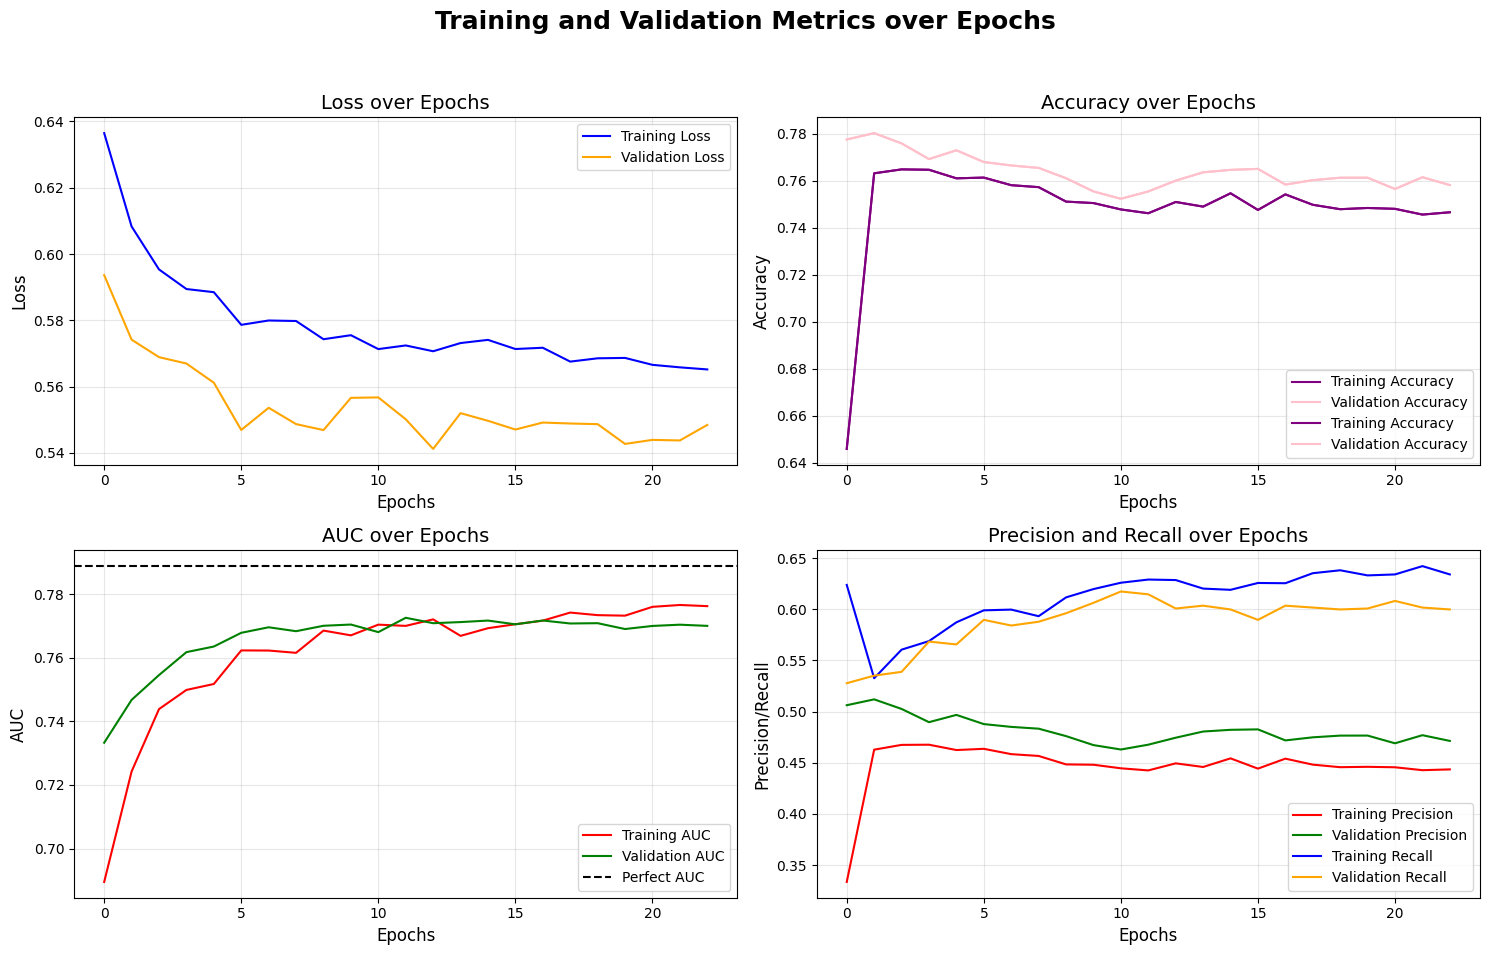

In [17]:
# ============ Visualization of Training Metrics over Epochs ==============

print("=" * 55)
print("TRAINING HISTORY VISUALIZATIONS")
print("=" * 55)

fig, axes = plt.subplots(2, 2, figsize=(15,10))
fig.suptitle("Training and Validation Metrics over Epochs", fontsize=18, fontweight='bold') # overall title for the figure

# Plotting Loss over Epochs
axes[0,0].plot(history.history['loss'], label="Training Loss", color="blue")
axes[0,0].plot(history.history['val_loss'], label="Validation Loss", color="orange")
axes[0,0].set_xlabel("Epochs", fontsize=12)
axes[0,0].set_ylabel("Loss", fontsize=12)
axes[0,0].set_title("Loss over Epochs", fontsize=14)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)


# Plotting Accuracy
axes[0,1].plot(history.history['accuracy'], label="Training Accuracy", color="purple")
axes[0,1].plot(history.history['val_accuracy'], label="Validation Accuracy", color="pink")
axes[0,1].set_xlabel("Epochs", fontsize=12)
axes[0,1].set_ylabel("Accuracy", fontsize=12)
axes[0,1].set_title("Accuracy over Epochs", fontsize=14)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)


# Plotting Accuracy
axes[0,1].plot(history.history['accuracy'], label="Training Accuracy", color="purple")
axes[0,1].plot(history.history['val_accuracy'], label="Validation Accuracy", color="pink")
axes[0,1].set_xlabel("Epochs", fontsize=12)
axes[0,1].set_ylabel("Accuracy", fontsize=12)
axes[0,1].set_title("Accuracy over Epochs", fontsize=14)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)


# Plotting AUC (Area Under the Curve)
axes[1,0].plot(history.history['auc'], label="Training AUC", color="red")
axes[1,0].plot(history.history['val_auc'], label="Validation AUC", color="green")
axes[1,0].axhline(y=0.7889, color="black", linestyle="--", label="Perfect AUC") # reference line for perfect AUC
axes[1,0].set_xlabel("Epochs", fontsize=12)
axes[1,0].set_ylabel("AUC", fontsize=12)
axes[1,0].set_title("AUC over Epochs", fontsize=14)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plotting AUC (Area Under the Curve)
axes[1,1].plot(history.history['precision'], label="Training Precision", color="red")
axes[1,1].plot(history.history['val_precision'], label="Validation Precision", color="green")
axes[1,1].plot(history.history['recall'], label="Training Recall", color="blue")
axes[1,1].plot(history.history['val_recall'], label="Validation Recall", color="orange")
axes[1,1].set_xlabel("Epochs", fontsize=12)
axes[1,1].set_ylabel("Precision/Recall", fontsize=12)
axes[1,1].set_title("Precision and Recall over Epochs", fontsize=14)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)



# show the plots 
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # adjust layout to make space for titles
plt.show()


#### EVALUATION 

In [ ]:
# ============ Evaluation of the Test Set ==============

'''
This section here will be used to evalaute the performance on the deep learning model on its test set of 20% of the data (6,000 samples)

Utilzing predict, confusion_matrix, classification report, and caluclate the models accuracy score and and ROC AUC score on the test set. 

This information will be compared against the statistical models from Assignment 3 

There is not predict_proba in Keras, so it will use predict() and apply a threshold

references: https://keras.io/api/models/model_training_apis/#evaluate-method
'''


# Make predictions on the test set 
print("-" * 50)
print("Making predictions on the test set...\n")

# get the predicted probabilities 
y_prediction_prob = model.predict(
    X_test_scaled,
    verbose=0
)

# convert probabilties to binary predictions using threshold, 
y_predictions = (y_prediction_prob >= 0.5).astype(int).flatten() # use of flatten to convert from a numpy 2D array back to a 1D array for compatibility. Transform it to s imple list-like structure

# Predicted versus actual 
actual_count = y_test.sum()
predicted_count = y_predictions.sum()

actual_mean = y_test.mean()*100
predicted_mean = y_predictions.mean()*100

print("Predictions on the test set are complete!\n")
print(f" Test set Size: {len(y_test):,} samples")
# True Positives versus False Positives/Negatives
print(f" Actual Defaults : {actual_count:,} defaults | {actual_mean:.2f}%")
print(f" Predicted defaults: {predicted_count:,} defaults | {predicted_mean:.2f}%")




--------------------------------------------------
Making predictions on the test set...

Predictions on the test set are complete!

 Test set Size: 6,000 samples
 Actual : 1,365 samples | 22.75%
 Predicted : 1,691 samples | 28.18%


In [37]:
# Continuing with the evaluation metrics and calculate the accuracy and ROC AUC score on the test set 

test_accuracy = accuracy_score(y_test, y_predictions)
test_roc_auc = roc_auc_score(y_test, y_prediction_prob)

# get th percentage of the accuracy score for interpretability 
test_acc_percentage = test_accuracy * 100


print(f"Accuracy: {test_accuracy:.4f} | {test_acc_percentage:.2f}%")
print(f"ROC AUC Score: {test_roc_auc:.4f}")



#====== Classfication Report and Confusion Matrix =======
print("-" * 50)
print("Classfication Report")
class_report = classification_report(
        y_test, 
        y_predictions,
        target_names=['No Default (0)', 'Default (1)'],
        digits=4,
)

print(class_report)

# need to extract Recall from the classification repport for the default comparison using output_dict. Will call it again but not print it and extract the data later

class_report_dict = classification_report(
        y_test, 
        y_predictions,
        target_names=['No Default (0)', 'Default (1)'],
        digits=4,
        output_dict=True
)

# calculate the confusion matrix 
conf_matrix = confusion_matrix(y_test, y_predictions)
print("-" * 50)
print("Confusion Matrix:")
print(conf_matrix)
print(f"\nCorrectly Predicted Non-Defaults (True Negatives): {conf_matrix[0,0]:,}")
print(f"Correctly Predicted Defaults (True Positives): {conf_matrix[1,1]:,}")
print("-" * 35)
print(f"Incorrectly Predicted Non-Defaults (False Positives): {conf_matrix[0,1]:,}")
print(f"Incorrectly Predicted Defaults (False Negatives): {conf_matrix[1,0]:,}")


# ===== Extract Recall from the classification report =========
'''
extractiing the recall for default class to get the percentage of actual defaulters as seen in the classiftication report

This is will be used to compare against Assignment 3 models 
'''

default_recall = class_report_dict["Default (1)"]["recall"]
default_recall_percentage = default_recall * 100

print("-" * 50)
print(f"Default Recall: {default_recall:.4f} | {default_recall_percentage:.2f}%")
print(f"Caught {conf_matrix[1,1]:,} out of {conf_matrix[1,:].sum():,} actual defaulters in the test set.")


Accuracy: 0.7663 | 76.63%
ROC AUC Score: 0.7839
--------------------------------------------------
Classfication Report
                precision    recall  f1-score   support

No Default (0)     0.8751    0.8136    0.8432      4635
   Default (1)     0.4891    0.6059    0.5412      1365

      accuracy                         0.7663      6000
     macro avg     0.6821    0.7097    0.6922      6000
  weighted avg     0.7873    0.7663    0.7745      6000

--------------------------------------------------
Confusion Matrix:
[[3771  864]
 [ 538  827]]

Correctly Predicted Non-Defaults (True Negatives): 3,771
Correctly Predicted Defaults (True Positives): 827
-----------------------------------
Incorrectly Predicted Non-Defaults (False Positives): 864
Incorrectly Predicted Defaults (False Negatives): 538
--------------------------------------------------
Default Recall: 0.6059 | 60.59%
Caught 827 out of 1,365 actual defaulters in the test set.


#### QUALITIATIVE ANALYSIS

In [44]:
  # View predictions and compare with actual results 
compare_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_predictions,
    'Probability': y_prediction_prob.flatten(), # convert from 2d to 1d array
    'Correct': y_test == y_predictions
})

# reset the index for readability to original test set
compare_df = compare_df.reset_index(drop=True)

# Number of samples to display 
n_samples = 10

 # safe check to ensure there are enough examples to sample from. Check for min against n_samples
n_correct = min(n_samples, compare_df[compare_df['Correct'] == True].shape[0])
n_incorrect = min(n_samples, compare_df[compare_df['Correct'] == False].shape[0])


# sample n examples from correct and incorrect predictions
correct_examples = compare_df[compare_df['Correct'] == True].sample(n=n_correct, random_state=RANDOM_STATE)
incorrect_examples = compare_df[compare_df['Correct'] == False].sample(n=n_incorrect, random_state=RANDOM_STATE)

 # display the examples 
print(f'Qualitative Analysis is complete!')
print("-" * 50)
print(f'Qualitative Analysis:\n')
print(f'----Correct Predictions ({len(correct_examples)} examples)----')
print(correct_examples.to_string(index=True))
print(f'\n----InCorrect Predictions ({len(incorrect_examples)} examples)----')
print(incorrect_examples.to_string(index=True)) # use to_string to display without the index for readability
print("-" * 50)



Qualitative Analysis is complete!
--------------------------------------------------
Qualitative Analysis:

----Correct Predictions (10 examples)----
      Actual  Predicted  Probability  Correct
2685       0          0     0.198094     True
1588       0          0     0.209884     True
1074       1          1     0.847786     True
2598       1          1     0.869446     True
3239       1          1     0.808001     True
4743       0          0     0.382776     True
5475       0          0     0.266980     True
5842       0          0     0.315157     True
1460       0          0     0.364042     True
440        0          0     0.183479     True

----InCorrect Predictions (10 examples)----
      Actual  Predicted  Probability  Correct
3707       0          1     0.536582    False
2766       0          1     0.547137    False
2761       1          0     0.342584    False
5667       1          0     0.441169    False
1443       1          0     0.356089    False
3868       1          0

## COMPARISON OF ALL THE MODELS

In [67]:
'''
In this section we will use the data from the model comparison in Assignment 3 and 
compare it against the Deep Learning models performance results. 

----------------------------------------------------------------
The Statistical Model from Assignment 3 results:

Model Comparison based on Accuracy Scores:

            Model Name  Accuracy Score  ROC AUC Score   Recall
1        Random Forest          0.8223         0.7727   0.37
2             LightGBM          0.8222         0.7889   0.36
0  Logistic Regression          0.8122         0.7249   0.24

----------------------------------------------------------------

From the Neural Network: deep learning model results:

Auccuracy: 0.8222 | 82.22%
ROC AUC Score: 0.7895
Default Recall: 0.6059 | 60.59%
Caught 827 out of 1,365 actual defaulters in the test set.

-----------------------------------------------------------------
Will implement a similair comparison table to the one from Assignment 3 for side by side comparison and sort by the 
ROC AUC score to match the findings from the Literature Review which stated AUC was a leading metric indicator for predicting 
credit risk and default.

'''

# comparison data for all models from A3 and deep learning in a dictionary format
comparison_data = [
    # Neural Network Model Data 
    {
        'Model Name': 'Neural Network: Deep Learning Model',
        'Accuracy Score': test_accuracy, 
        'ROC AUC Score': test_roc_auc,
        'Recall': default_recall
    },
    #========== Assignment 3 Models ==========
    {
        'Model Name': 'LightGBM Model',
        'Accuracy Score': 0.8222, 
        'ROC AUC Score': 0.7889,
        'Recall': 0.36
    },
    {
        'Model Name': 'Random Forest Model',
        'Accuracy Score': 0.8223, 
        'ROC AUC Score': 0.7727,
        'Recall': 0.37
        
    },
    {
        'Model Name': 'Logistic Regression Model',
        'Accuracy Score': 0.8122, 
        'ROC AUC Score': 0.7249,
        'Recall': 0.24
        
    },   
]

# convert comparison data dictionary into a dataframe for better visualization and to sort
comparison_df = pd.DataFrame(comparison_data)

# sort the dataframe by ROC AUC Score in descending order
comparison_df = comparison_df.sort_values(by="ROC AUC Score", ascending=False)

print("=" * 50)
print("Model Performance Comparison")
print("=" * 50)

# display comparison table with no index
print(comparison_df.to_string(index=False))
print("-" * 80)


# ----- Best ROC AUC Score -----
print("Best ROC AUC Score:\n")
print(f"Best ROC AUC Score from A3: {comparison_df.iloc[0]['Model Name']} with a ROC AUC Score of {comparison_df.iloc[0]['ROC AUC Score']}")
print(f"Neural Network ROC AUC Score: {comparison_df.iloc[1]['ROC AUC Score']:.4f}")
print(f"Overall Model with the Best ROC AUC Score: {comparison_df.iloc[0]['Model Name']}")
if test_roc_auc < comparison_df.iloc[0]['ROC AUC Score']:
    print(f" (Deep Learning model is {comparison_df.iloc[0]['ROC AUC Score'] - test_roc_auc:.4f} lower than LightGBM)")
else:
    print(f" (Deep Learning model is {test_roc_auc - comparison_df.iloc[0]['ROC AUC Score']:.4f} higher than LightGBM)")
    
print("-" * 80)
# ----- Best Accuracy Score -----
print("Best Accuracy Score:\n")
print(f"Best Accuracy Score from A3: {comparison_df.iloc[2]['Model Name']} with an Accuracy Score of {comparison_df.iloc[2]['Accuracy Score']}")
print(f"Neural Network Accuracy Score: {comparison_df.iloc[1]['Accuracy Score']:.4f}")
print(f"Overall Model with the Best Accuracy Score: {comparison_df.iloc[2]['Model Name']}")
if test_accuracy < comparison_df.iloc[2]['Accuracy Score']:
    print(f" (Deep Learning model is {comparison_df.iloc[2]['Accuracy Score'] - test_accuracy:.4f} lower than Random Forest)")
else:
    print(f" (Deep Learning model is {test_accuracy - comparison_df.iloc[2]['Accuracy Score']:.4f} higher than Random Forest)")

print("-" * 80)
# ----- Best Recall Score -----
print("Best Recall Score:\n")
print(f"Best Recall Score from A3: {comparison_df.iloc[2]['Model Name']} with a Recall Score of {comparison_df.iloc[2]['Recall']}")
print(f"Neural Network Recall Score: {comparison_df.iloc[1]['Recall']:.4f}")
print(f"Overall Model with the Best Recall Score: {comparison_df.iloc[1]['Model Name']}")
if default_recall < comparison_df.iloc[1]['Recall']:
    print(f" (Deep Learning model is {comparison_df.iloc[1]['Recall'] - default_recall:.4f} lower than Randoom Forest)")
else:
    print(f" (Deep Learning model is {default_recall - comparison_df.iloc[2]['Recall']:.4f} higher than Random Forest)")


Model Performance Comparison
                         Model Name  Accuracy Score  ROC AUC Score   Recall
                     LightGBM Model        0.822200       0.788900 0.360000
Neural Network: Deep Learning Model        0.766333       0.783942 0.605861
                Random Forest Model        0.822300       0.772700 0.370000
          Logistic Regression Model        0.812200       0.724900 0.240000
--------------------------------------------------------------------------------
Best ROC AUC Score:

Best ROC AUC Score from A3: LightGBM Model with a ROC AUC Score of 0.7889
Neural Network ROC AUC Score: 0.7839
Overall Model with the Best ROC AUC Score: LightGBM Model
 (Deep Learning model is 0.0050 lower than LightGBM)
--------------------------------------------------------------------------------
Best Accuracy Score:

Best Accuracy Score from A3: Random Forest Model with an Accuracy Score of 0.8223
Neural Network Accuracy Score: 0.7663
Overall Model with the Best Accuracy Score: 